# 04 · Supervision and validation before image-model comparisons

**Question:** On the same training reports, how do negation, uncertainty, and clinical context change target candidates when used jointly, and what changes when each block is removed?

**Current evidence:** Previous acquisition and one-series image feature construction are complete. No image model has been fitted and no AUC has been measured. This notebook does not change that fact or touch the 58 sealed expert outcomes.

**Run:** Use **RSNA Knee - audit**. First run `python research/supervision/run.py prepare` in the project terminal. Then Restart Kernel and Run All Cells. Every chart emits both interactive Plotly data and a separate saved PNG companion, automatically on every run. Save and reopen before collecting the return.

**Budget:** Up to 256 training report groups, five matched extraction arms, no image downloads, no model/API calls, zero model fits. The first bounded analysis saves a checkpoint; the second must verify it and process zero new reports. Clinical accuracy, patient independence and multilingual coverage remain unverified.

**Important:** English lexical candidates are an exploratory reference, not production labels or test-time features. Read `research/supervision/README.md` and `SOURCES.md` for definitions, rationale and limits.


In [1]:
from pathlib import Path
import sys
ROOT = Path.home() / 'rsna-knee-abnormality-detection'
STAGE = ROOT / 'research' / 'supervision'
if not STAGE.is_dir():
    raise RuntimeError('Install the supervision package into the existing project first.')
if Path(sys.prefix).resolve() != (ROOT / '.venv').resolve():
    raise RuntimeError('Select RSNA Knee - audit, then restart the kernel.')
sys.path.insert(0, str(STAGE))
from common import require_tests, read_json, WORK
from pipeline import checked_previous, current_run
from run import launch_analysis
from plots import display_saved, finalize_figures
TESTS = require_tests()
CONFIG, PROTECTED = checked_previous()
print('Passing synthetic tests:', TESTS['tests'])
print('Previous source, metadata, completed stage keys and notebooks are preserved.')
print('58 expert-labeled studies remain sealed. No account or download action occurs.')


Passing synthetic tests: 80
Previous source, metadata, completed stage keys and notebooks are preserved.
58 expert-labeled studies remain sealed. No account or download action occurs.


## A · Freeze report-group allocation and run the paired supervision pilot

Study/report groups are assigned without using expert outcome values. The existing image-pilot groups remain training-only. Fold zero is development-only, while folds one to four supply this fixed sample. Exact normalized reports are not patient IDs; this does not establish patient/site independence.

The five arms see identical reports: mention-only reference, joint context, and three joint-minus-one-block comparisons. A candidate assignment difference is not an accuracy or AUC difference.


In [2]:
FIRST = launch_analysis()
assert FIRST['status'] == 'complete' and FIRST['model_fits'] == 0
assert FIRST['official_auc'] is None
print('First invocation status:', FIRST['stage'])


{"utc": "2026-09-14T17:43:08.212934+00:00", "stage": "split", "event": "reading_metadata", "completed": 0, "total": 1, "elapsed_seconds": 0.021, "stage_seconds": 0.0, "rss_mib": 38.5}
{"utc": "2026-09-14T17:43:08.698283+00:00", "stage": "split", "event": "assignment_written", "completed": 1, "total": 1, "elapsed_seconds": 0.506, "stage_seconds": 0.485, "rss_mib": 48.2}
{"utc": "2026-09-14T17:43:08.806904+00:00", "stage": "assertion_comparisons", "event": "working", "completed": 32, "total": 256, "elapsed_seconds": 0.615, "stage_seconds": 0.0, "rss_mib": 48.6}
{"utc": "2026-09-14T17:43:08.945153+00:00", "stage": "assertion_comparisons", "event": "working", "completed": 64, "total": 256, "elapsed_seconds": 0.753, "stage_seconds": 0.138, "rss_mib": 48.6}
{"utc": "2026-09-14T17:43:09.063761+00:00", "stage": "assertion_comparisons", "event": "working", "completed": 96, "total": 256, "elapsed_seconds": 0.872, "stage_seconds": 0.257, "rss_mib": 48.6}
{"utc": "2026-09-14T17:43:09.181745+00:00"

## B · Verify exact checkpoint reuse before interpreting the figures

This is a completed-stage restart check, not a simulation of every possible interruption. Correctly saved work is reused; a lineage or checksum mismatch stops the milestone.


In [3]:
SECOND = launch_analysis()
assert SECOND['key'] == FIRST['key']
assert SECOND['stage'] == 'reused_verified'
assert SECOND['new_reports_processed'] == 0
DIRECTORY, SUMMARY = current_run()
assert SUMMARY['gold_outcomes_used'] is False
assert SUMMARY['training_targets_approved'] is False
assert SUMMARY['groups_crossing_training_development'] == 0
print('SUPERVISION_CHECKPOINT_REUSED; new reports processed: 0')
print('Same reports per arm:', SUMMARY['sampled_reports'])
print('Candidate target cells per arm:', SUMMARY['label_cells_per_arm'])
print('Gold outcome analysis: none. Clinical accuracy: not measured. Image-model AUC: not measured.')


SUPERVISION_CHECKPOINT_REUSED
SUPERVISION_CHECKPOINT_REUSED; new reports processed: 0
Same reports per arm: 256
Candidate target cells per arm: 3072
Gold outcome analysis: none. Clinical accuracy: not measured. Image-model AUC: not measured.


## 01 · Study allocation

All expert studies remain sealed; additional matching reports are excluded from the training pool.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Study allocation - expert outcomes remain sealed**

These are availability-based splits, not disease prevalence or verified patient groups.

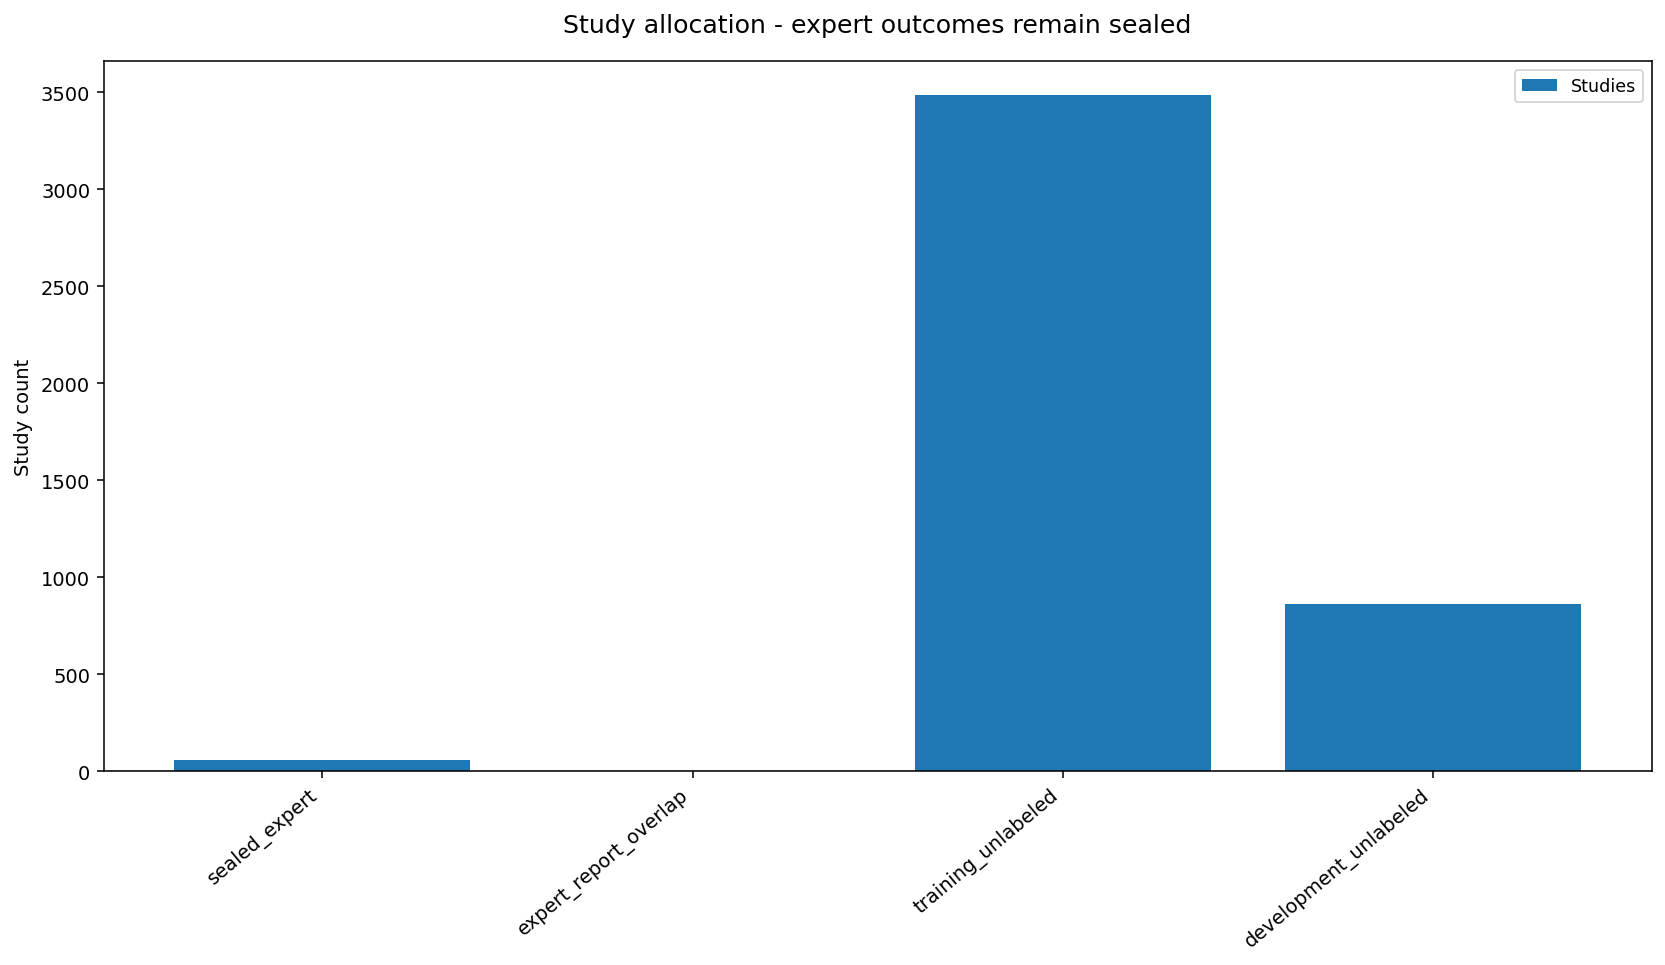

In [4]:
display_saved(1)


## 02 · Report-group folds

Counts describe report groups, not disease balance. Patient and site identity have not been established.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Distinct report groups in the frozen five-fold assignment**

Fold zero is reserved for later development checks; the candidate pilot uses folds 1-4 only.

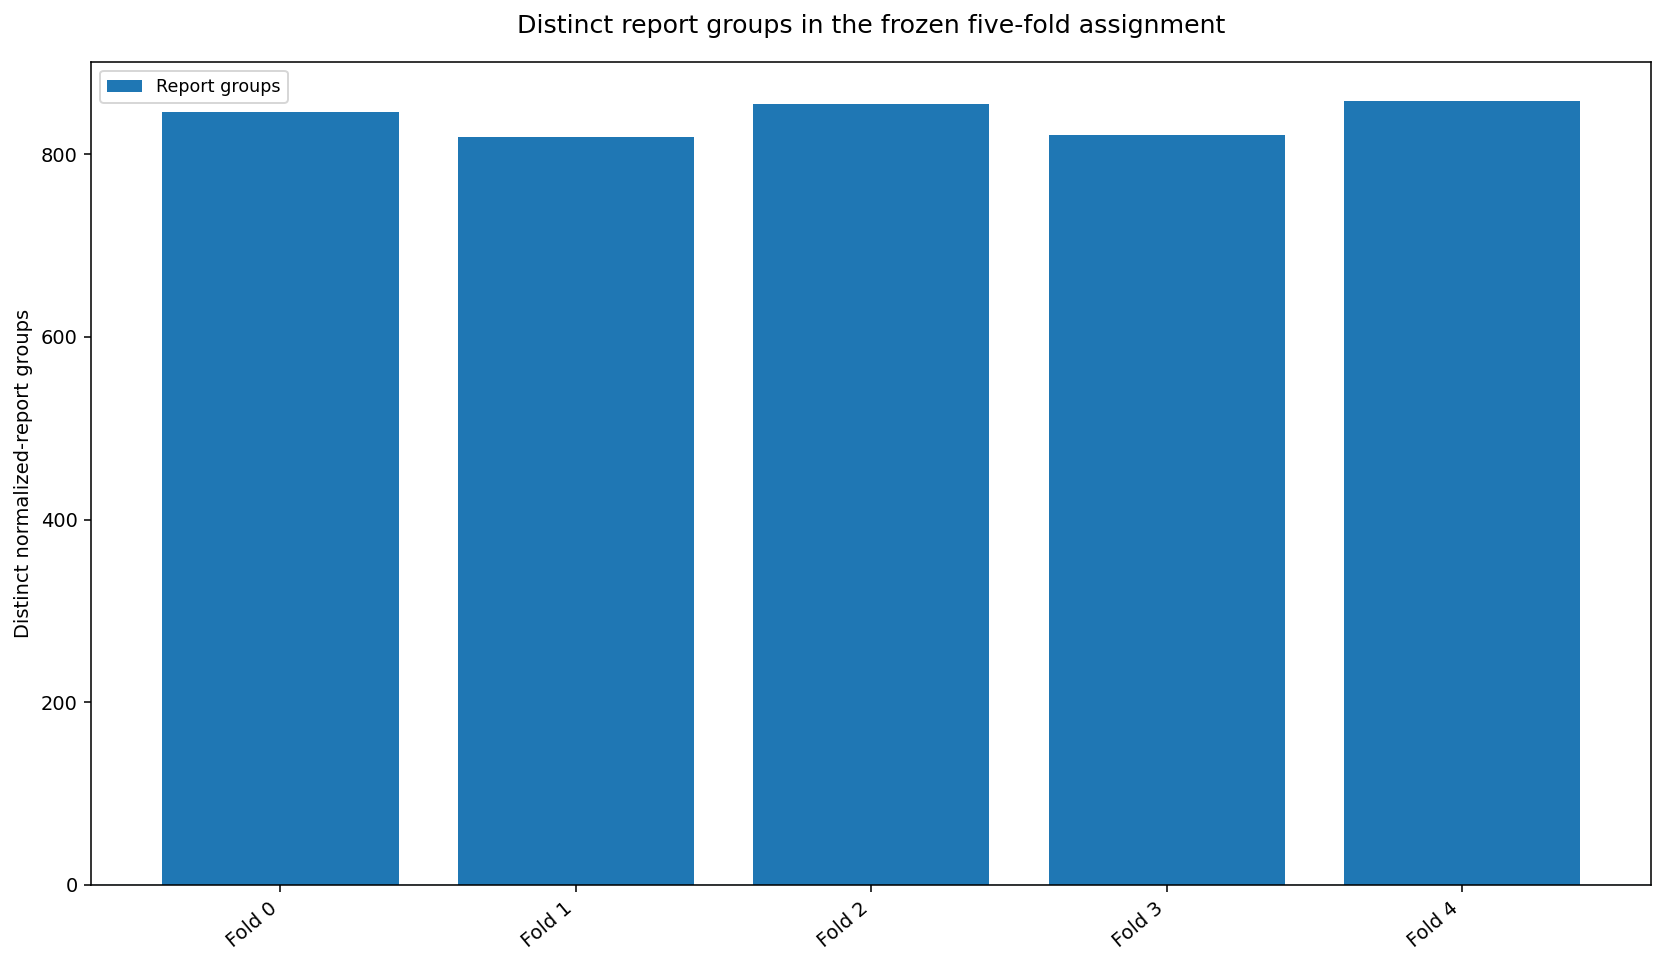

In [5]:
display_saved(2)


## 03 · Script coverage, not language identification

Latin-script text is not automatically English. The prototype only implements English lexical scope.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Unicode script presence in sampled training reports - not language identity**

One report can contain multiple scripts; Latin script does not establish English-language support.

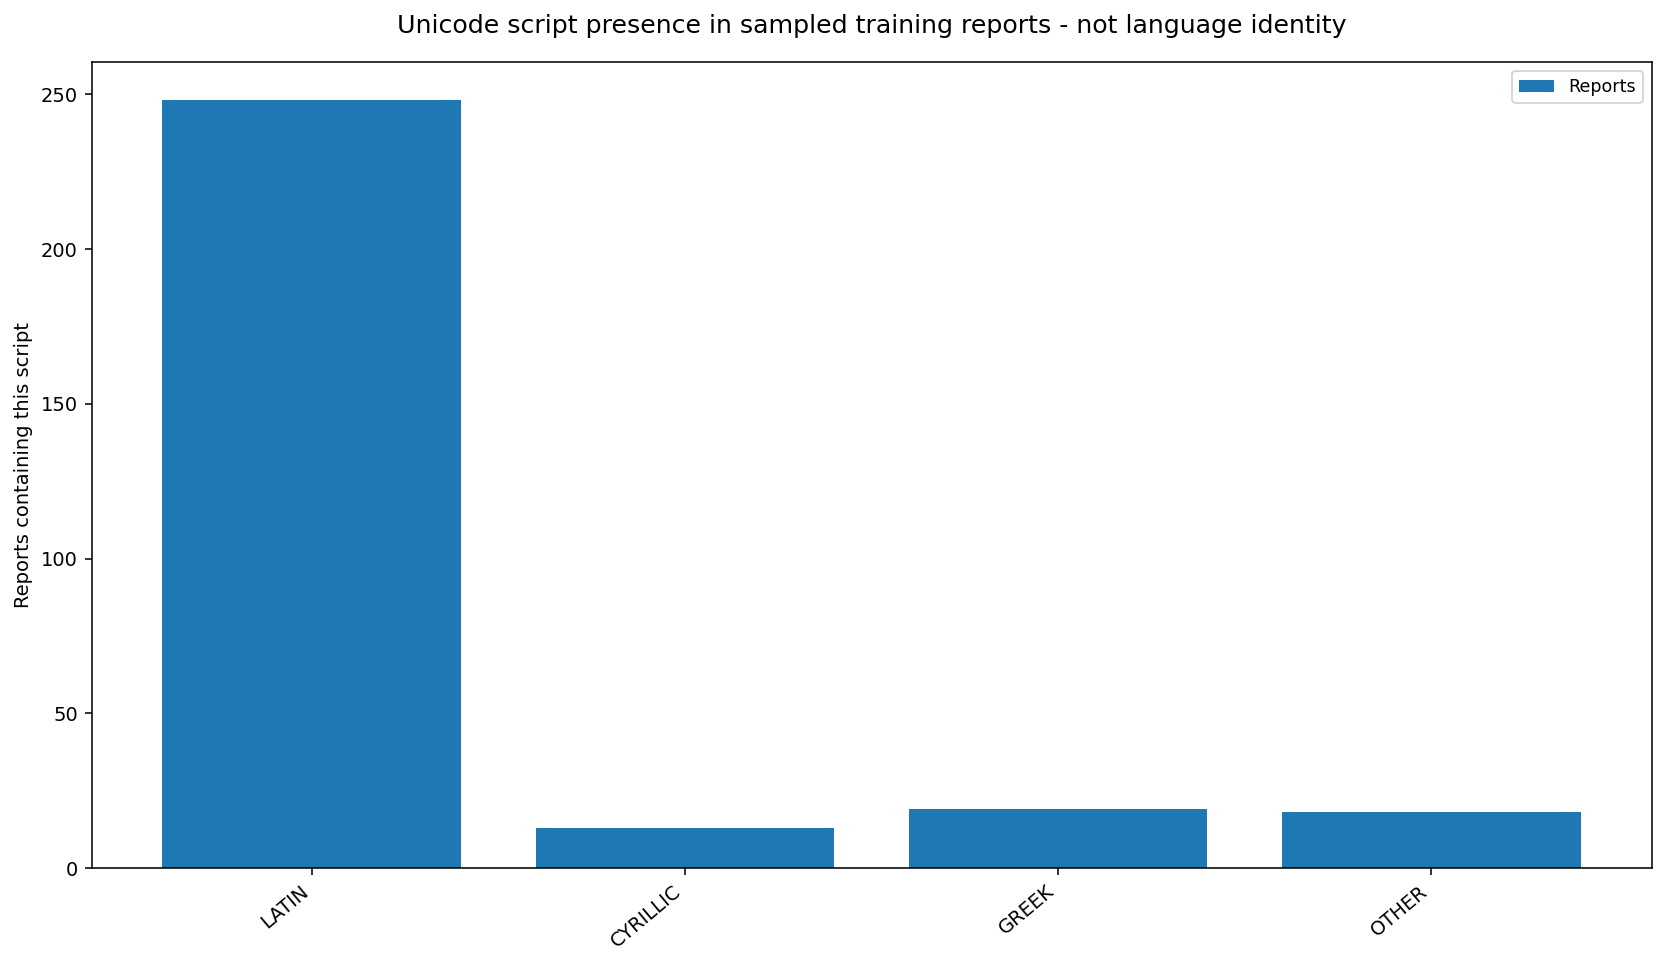

In [6]:
display_saved(3)


## 04 · Joint assertion-state panel

Positive, negative, uncertain, conflicting, contextual and unmentioned findings remain distinct.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Joint-context supervision candidates - six distinct states**

Candidate state counts are not clinical labels. English lexical scope has not been adjudicated.

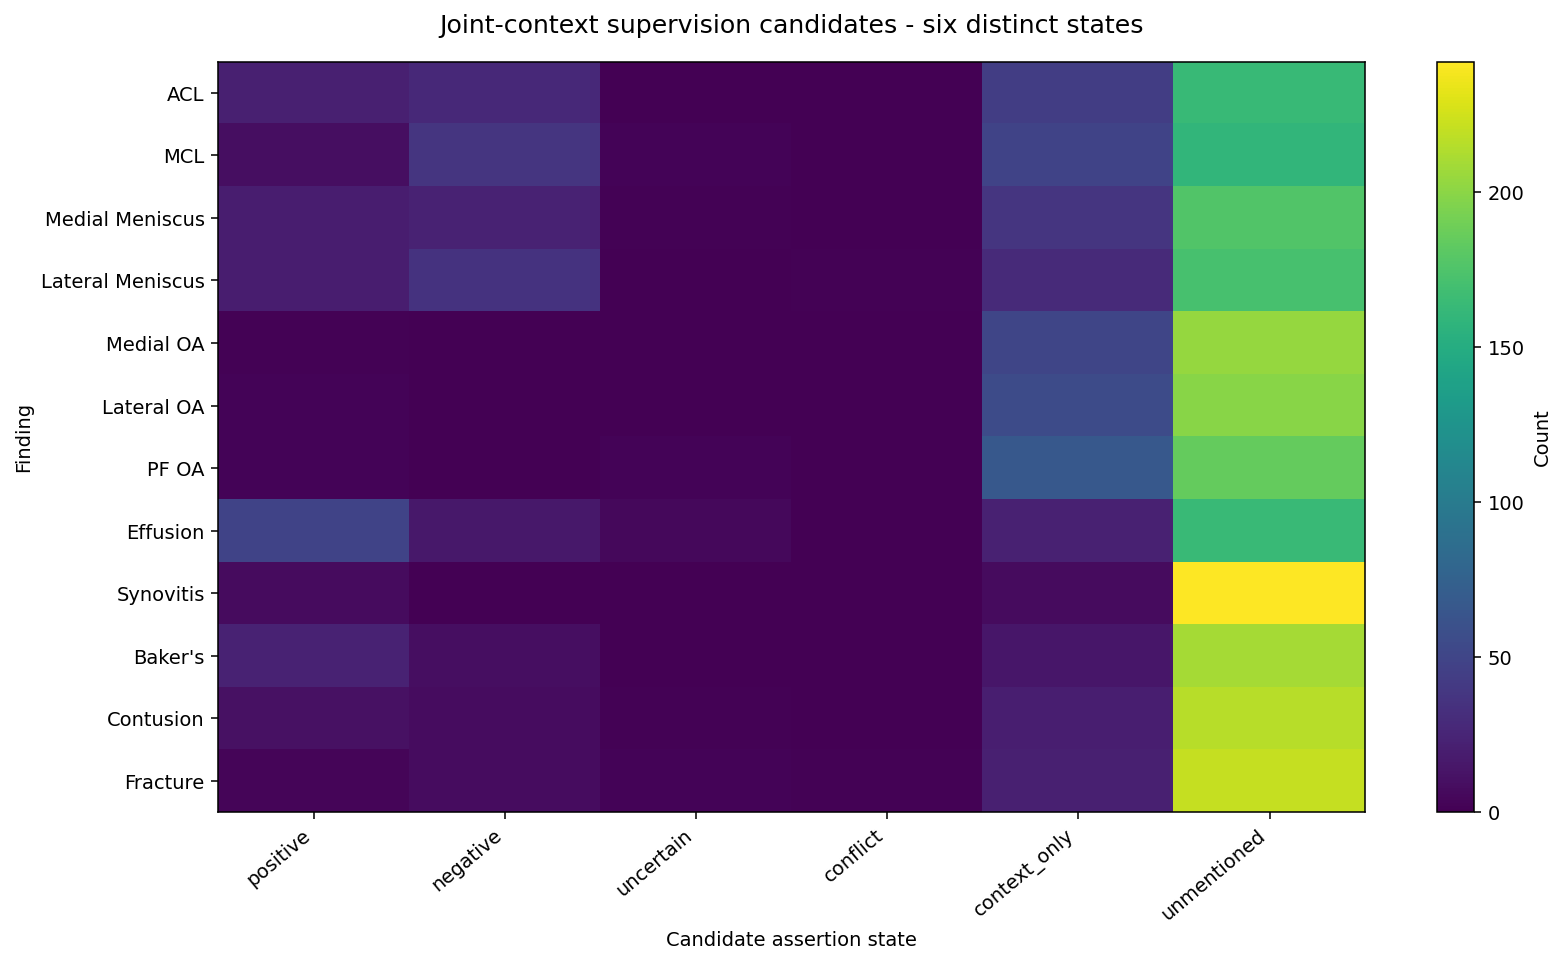

In [7]:
display_saved(4)


## 05 · Mention-only versus full joint construction

The joint pipeline is evaluated as a complete construction, not only by isolated ingredient counts.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Mention-only versus joint context - positive-candidate counts**

Both methods see the same sampled reports. A reduction in positives does not establish accuracy.

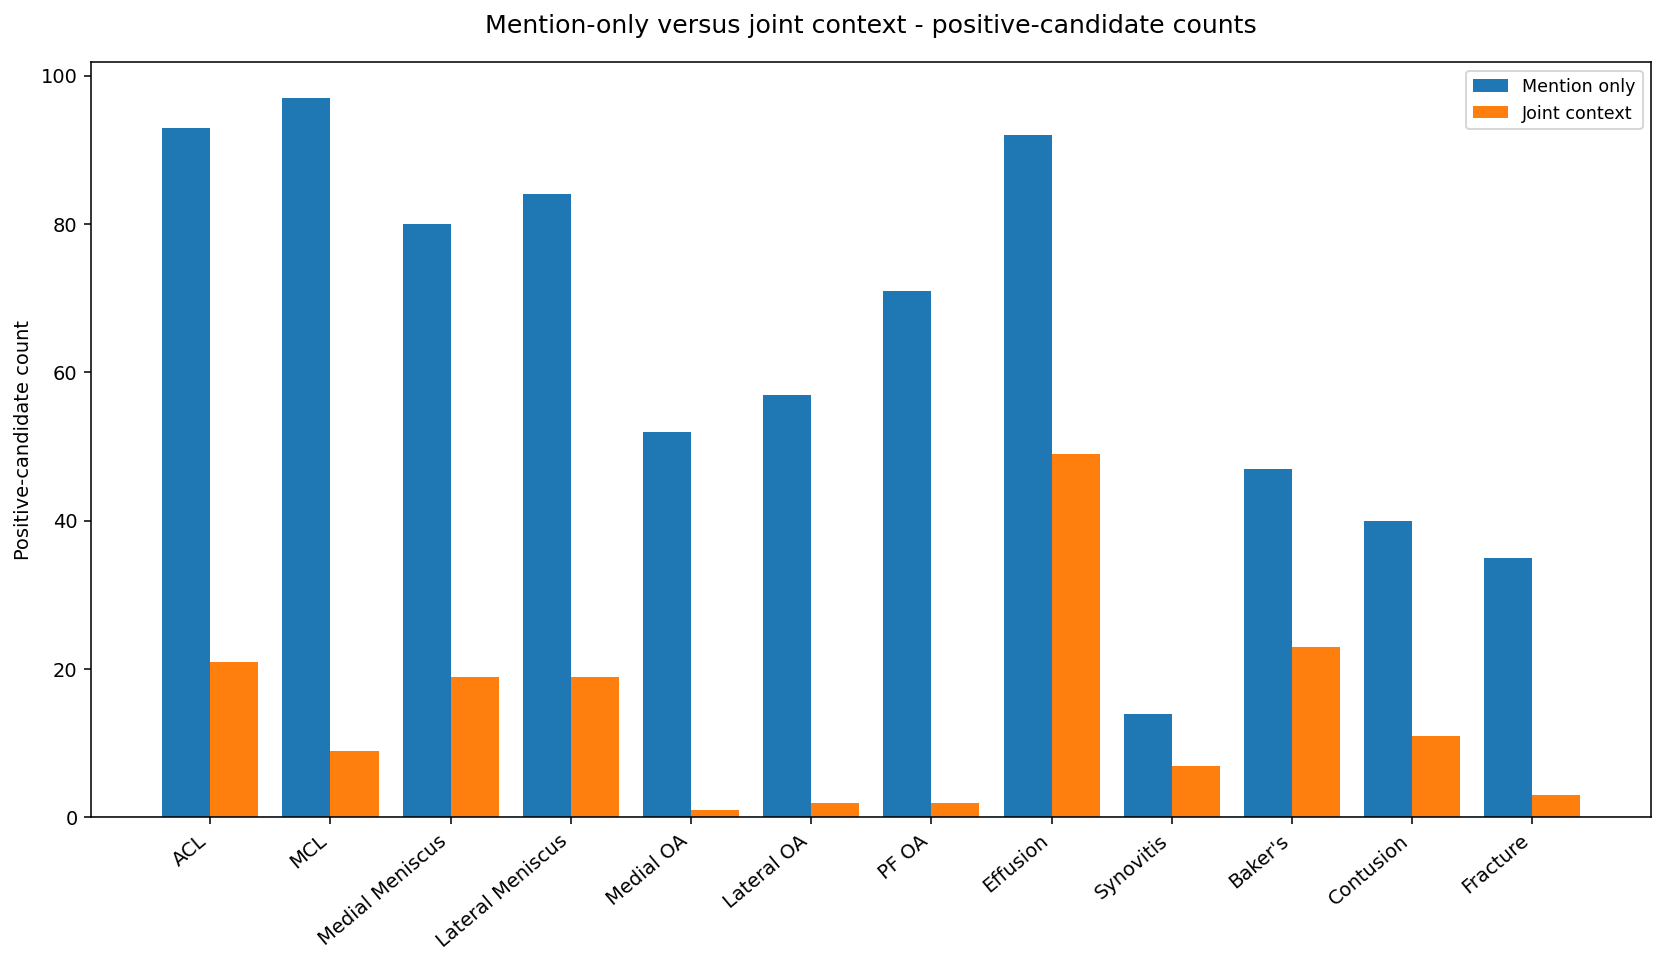

In [8]:
display_saved(5)


## 06 · Remove negation from the joint construction

This is a matched leave-one-block-out experiment. Candidate changes do not establish which assignment is correct.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Negation ablation - changes relative to the joint pipeline**

Removing a block from the full pipeline tests its conditional effect on assignments, not AUC.

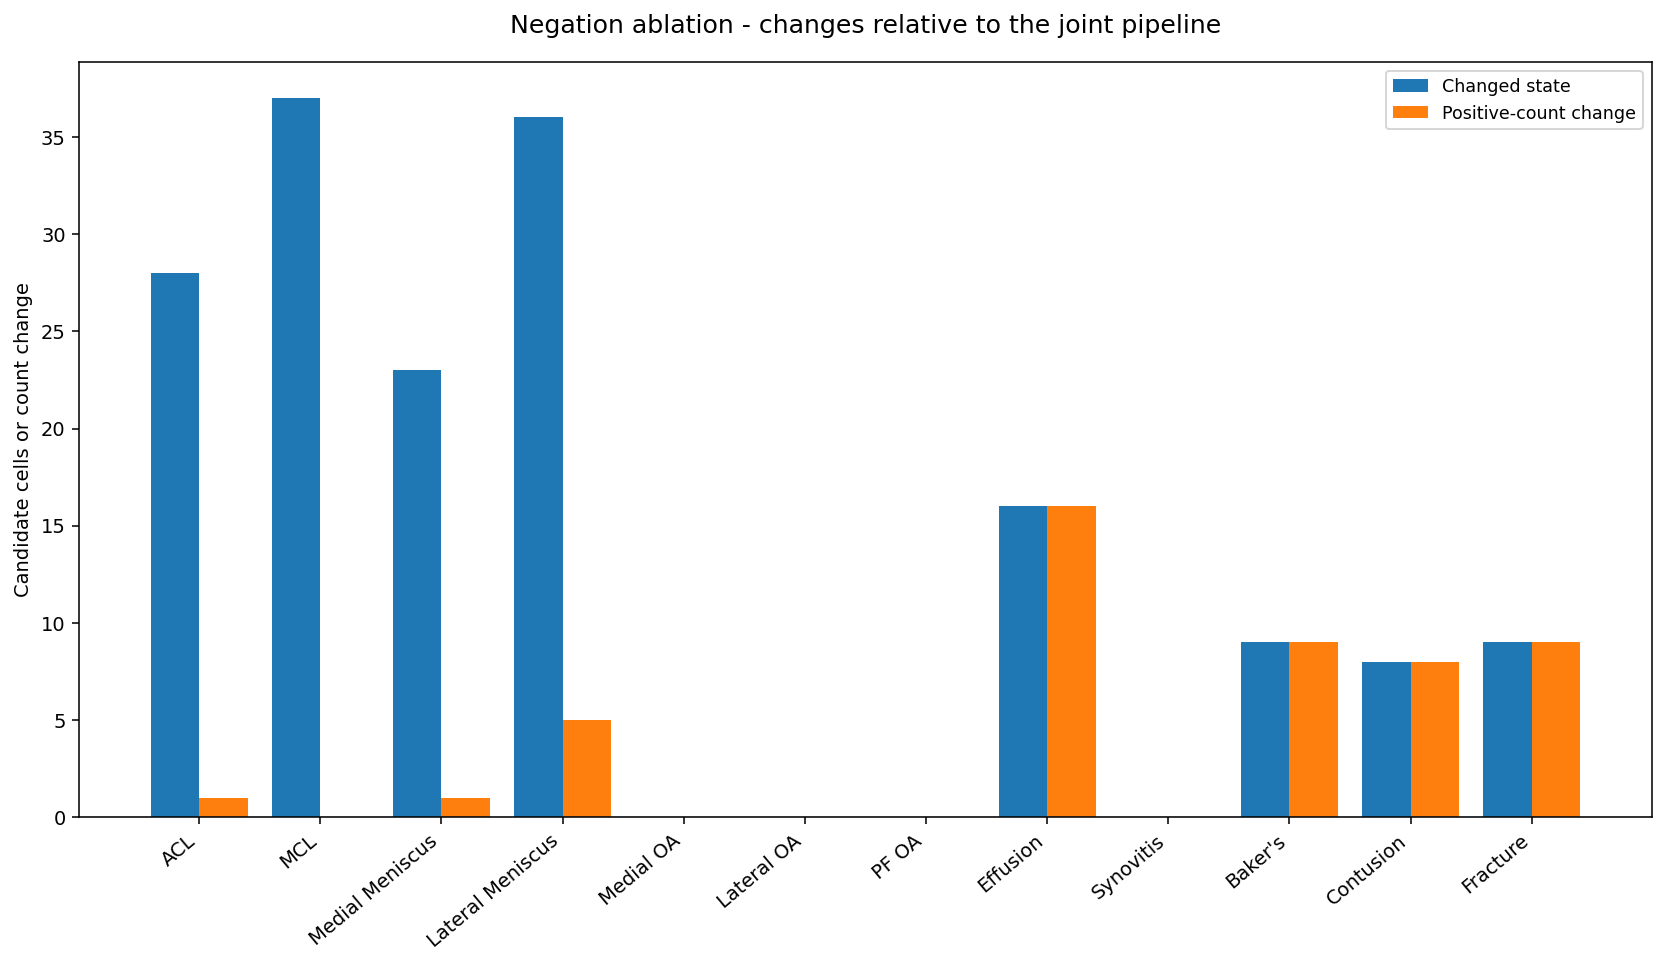

In [9]:
display_saved(6)


## 07 · Remove uncertainty from the joint construction

Uncertainty handling is compared on the exact same inputs, without forcing missing values to zero.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Uncertainty ablation - changes relative to the joint pipeline**

Uncertain findings remain masked under the joint pipeline; no numeric probability is assigned.

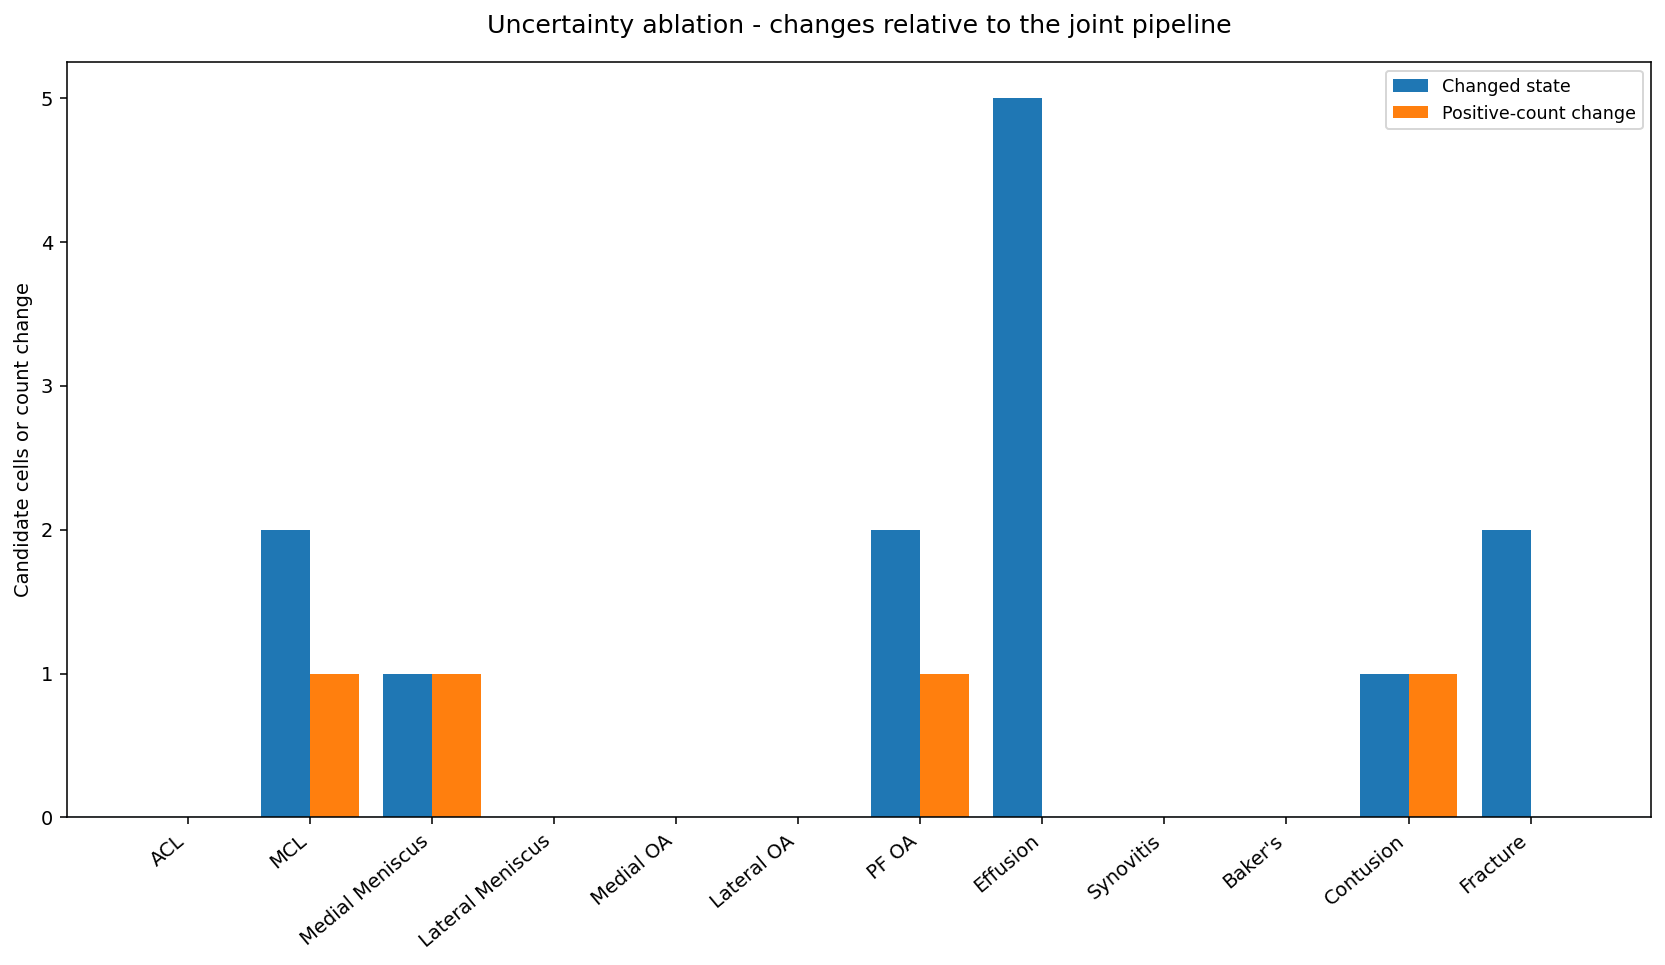

In [10]:
display_saved(7)


## 08 · Remove section/history handling from the joint construction

Clinical history and current findings must not be silently treated as the same event.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Section and history ablation - changes relative to the joint pipeline**

The joint context gate separates clinical history, indications and postoperative context from current findings.

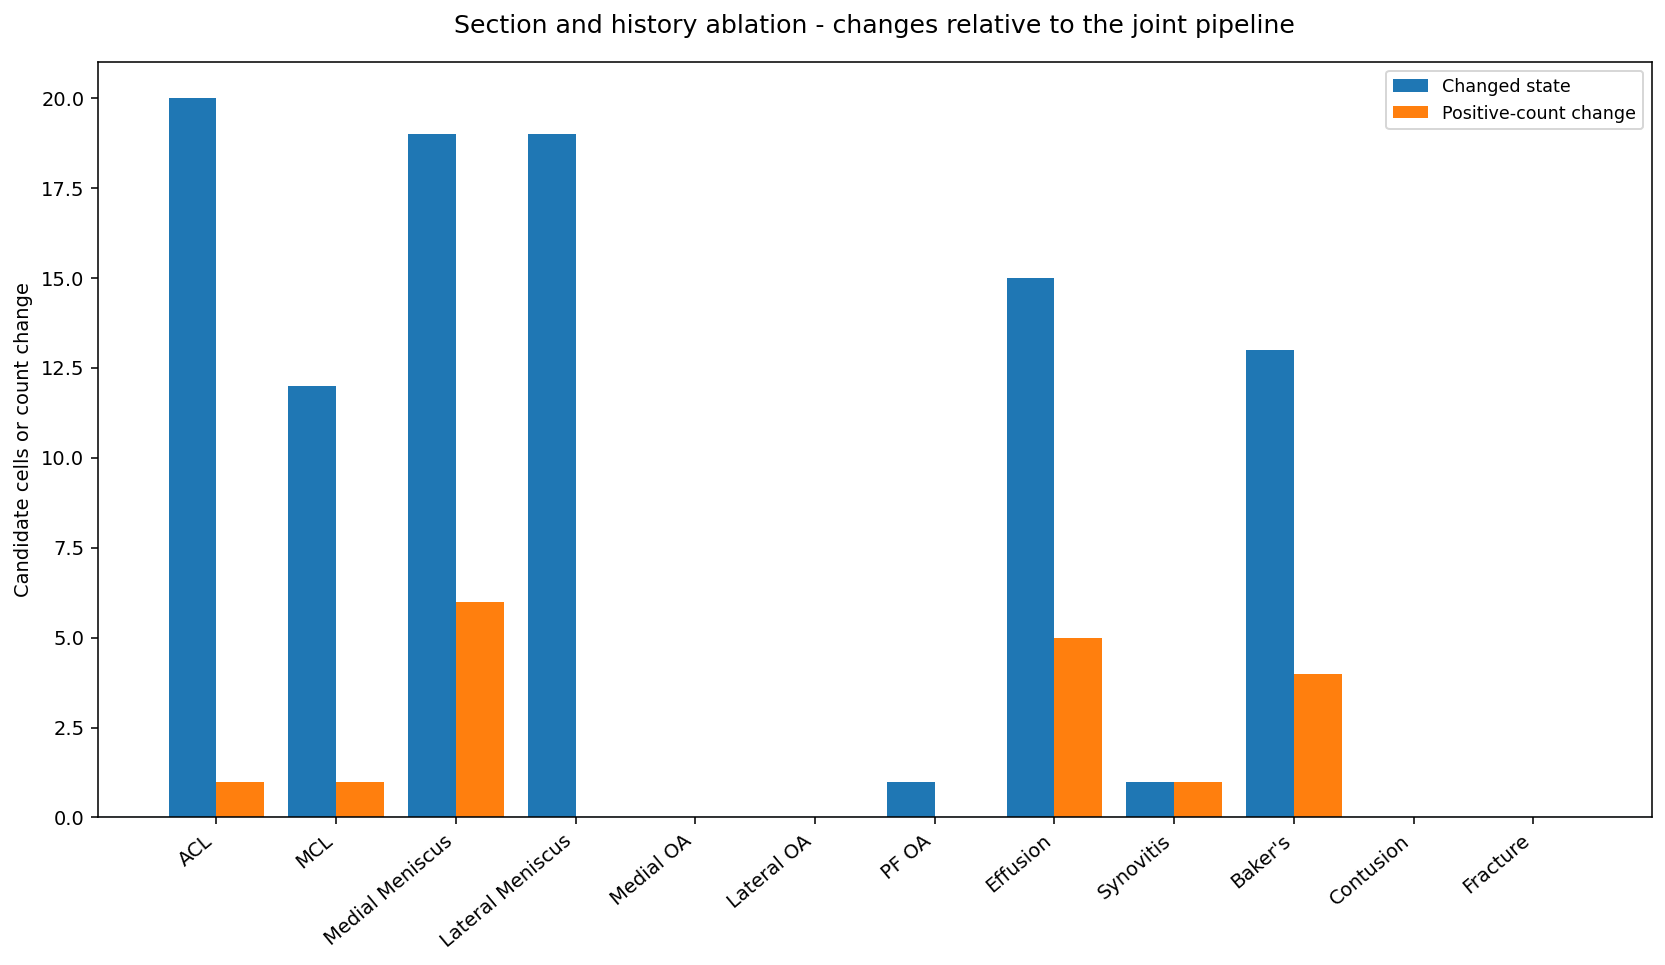

In [11]:
display_saved(8)


## 09 · Explicit negative candidates

Explicit negative evidence differs from a report that never mentions the finding.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Explicit negative candidates by finding**

Absence requires explicit negative evidence. Unmentioned findings are never silently converted to zero.

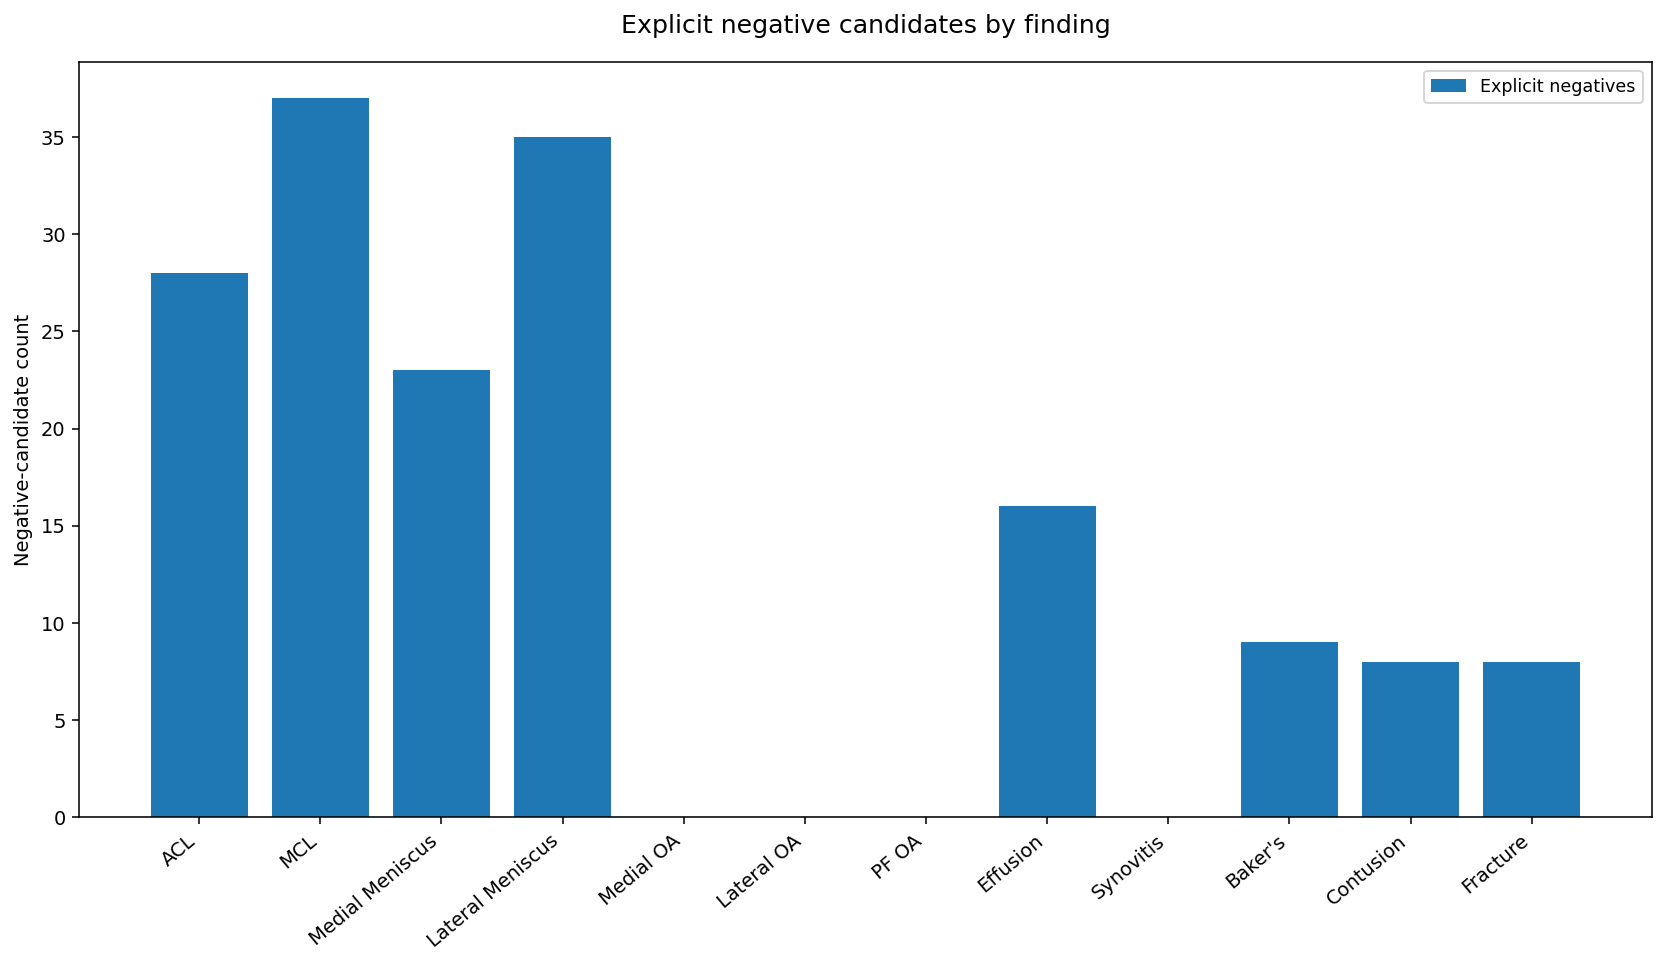

In [12]:
display_saved(9)


## 10 · Conflicting candidates

Conflicts remain unresolved rather than being converted into a confident target.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Conflicting assertion candidates by finding**

Conflicting positive and negative evidence is retained as conflict, not resolved by a guessed priority.

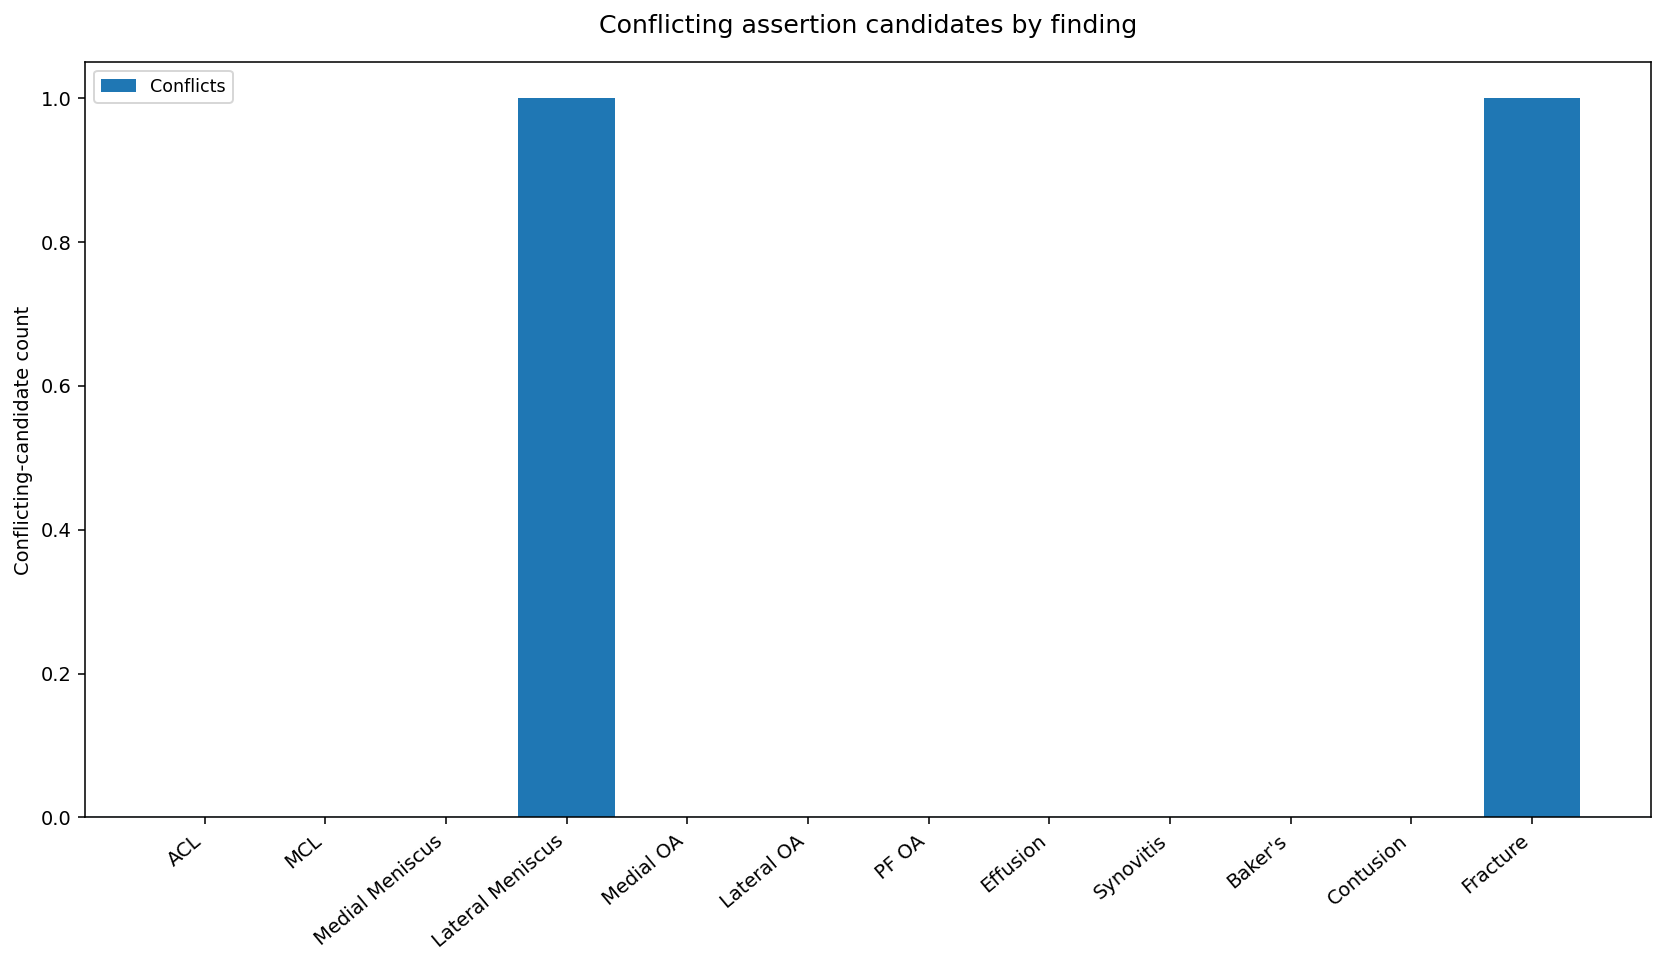

In [13]:
display_saved(10)


## 11 · Abstention patterns

No candidate target has been approved for training. Broad abstention may reflect language or vocabulary limitations.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Abstention by finding - uncertainty is not a negative label**

All nonbinary states are abstentions. No candidate target is approved for image-model training.

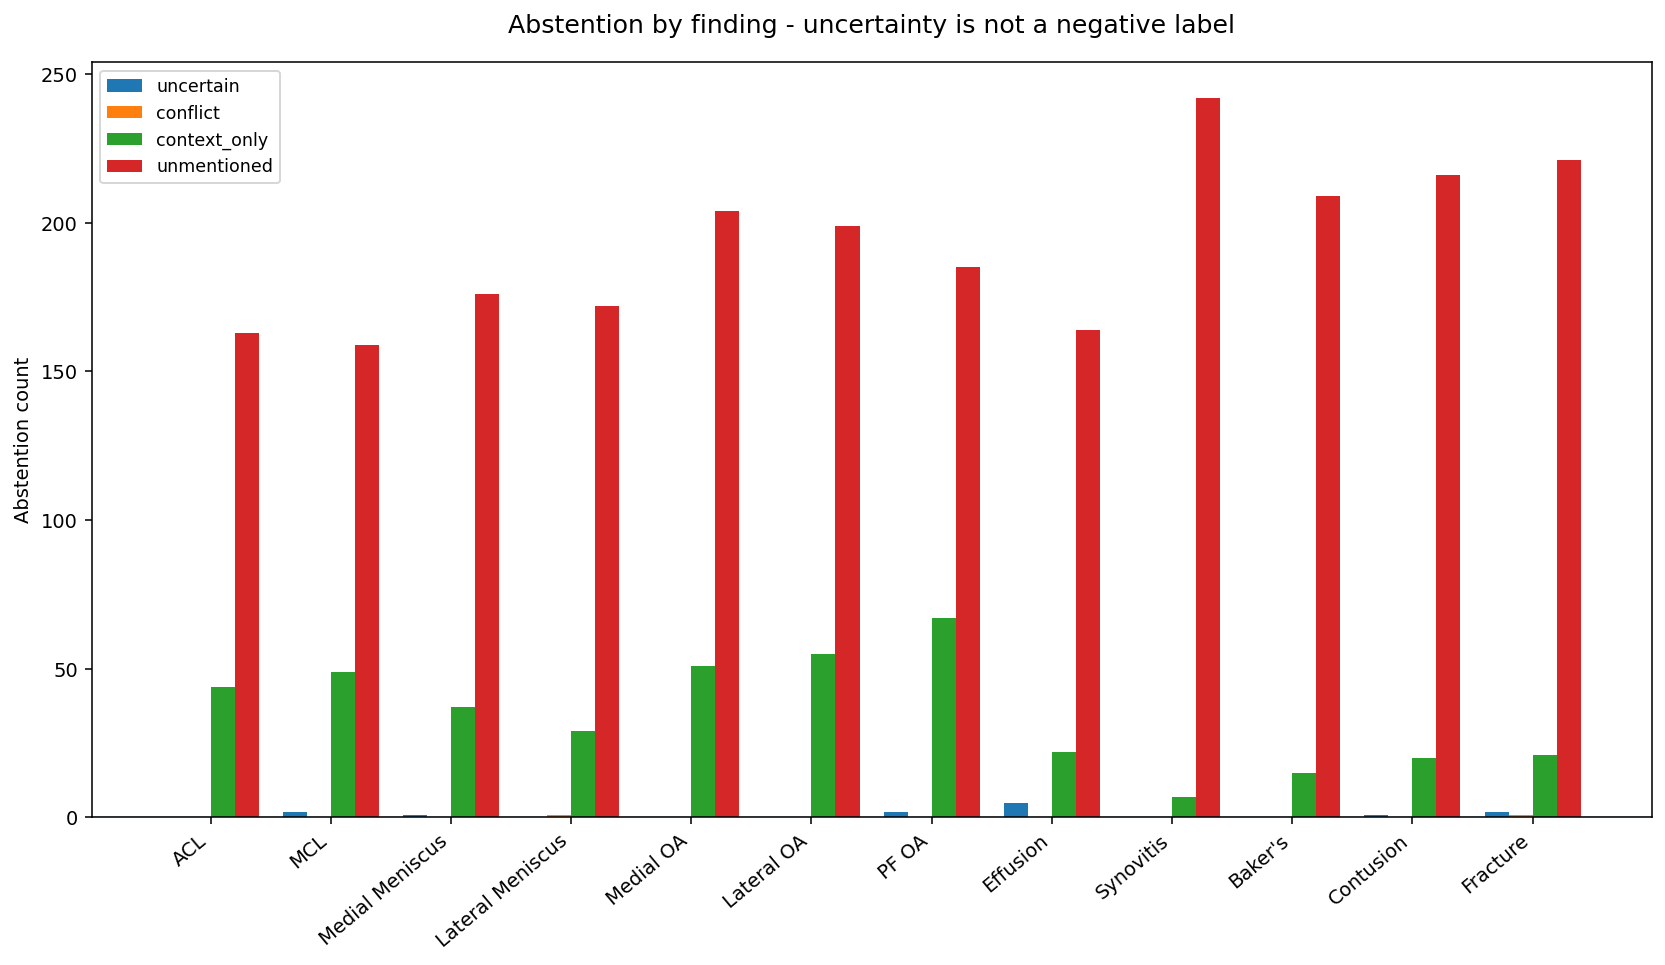

In [14]:
display_saved(11)


## 12 · Shared evidence coverage

This is evidence-coverage overlap, not disease co-occurrence and not justification for imputing one diagnosis from another.

Each figure saves its numerical specification, native Plotly JSON, interactive HTML, and PNG companion. The PNG is emitted separately and remains in the saved notebook.


**Shared binary-evidence coverage - not disease co-occurrence**

This matrix describes where reports contain binary assertions for both findings, not their diagnoses.

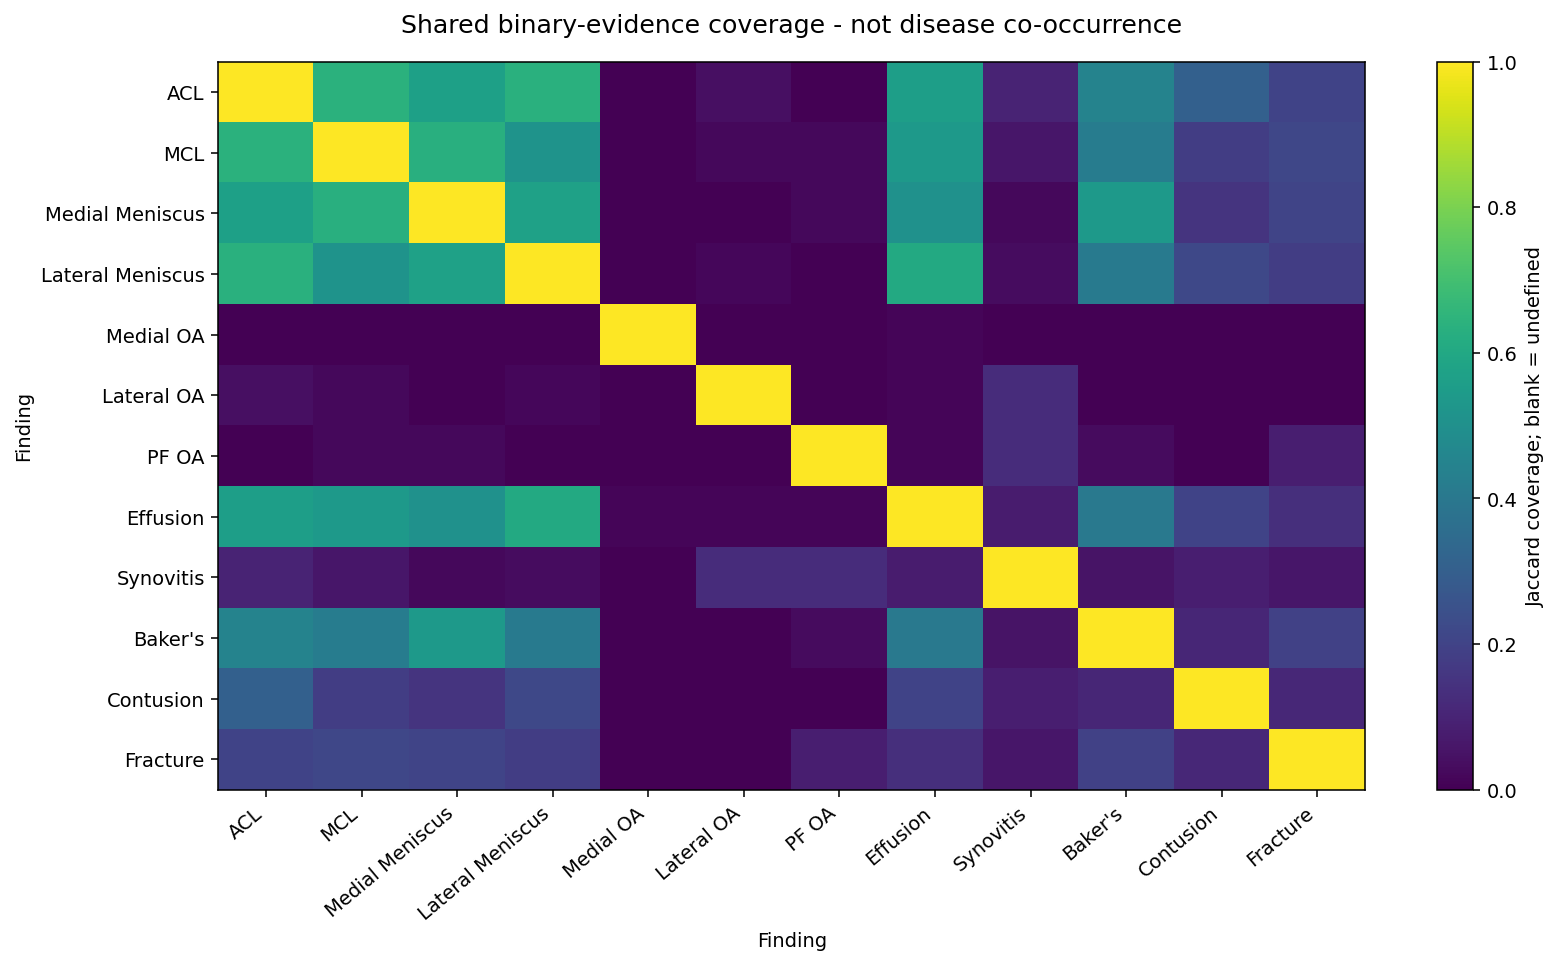

In [15]:
display_saved(12)


## Decision and handoff

We have measured how supervision candidates change, not whether they are clinically correct or improve image-model AUC. Preserve the 58 expert-labeled studies and the frozen development assignment. The next decision is whether coverage and scope justify a multilingual teacher/adjudication comparison before training on these targets.

Keep the disagreement review queue private. It is deliberately enriched for difficult reports and is not a random accuracy sample. Do not upload report text or use the unapproved states as model targets.

Save with **Ctrl+S**, close and reopen this notebook, and confirm all twelve PNG figures appear. Then run the terminal collection command below. Do not rerun earlier notebooks or the old return helper.


In [16]:
FIGURE_DIRECTORY = finalize_figures()
print('SUPERVISION_MILESTONE_COMPLETE')
print('12 Plotly figures and 12 PNG companions saved; no feature or label promotion.')
print('Model fits: 0 | Official AUC: not measured | Clinical label accuracy: not established')
print('Save this notebook now with Ctrl+S, then close and reopen it.')
print('Terminal command: python research/supervision/run.py collect')
print('Expected return: returns/rsna-knee-supervision-return.zip')


SUPERVISION_MILESTONE_COMPLETE
12 Plotly figures and 12 PNG companions saved; no feature or label promotion.
Model fits: 0 | Official AUC: not measured | Clinical label accuracy: not established
Save this notebook now with Ctrl+S, then close and reopen it.
Terminal command: python research/supervision/run.py collect
Expected return: returns/rsna-knee-supervision-return.zip
